In [3]:
%matplotlib inline

import os
import joblib
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
from joblib import Parallel, delayed
from sklearn.decomposition import PCA

# Plot Functions

In [4]:
# ====================================================================
# HELPER UTILITIES
# ====================================================================
def squeeze_curves(ori_curves):
    """Ensures input curves are 2D (N, T) by squeezing single channels if 3D."""
    if ori_curves.ndim == 3:
        return np.squeeze(ori_curves, axis=-1)
    return ori_curves

def get_base_label(label):
    """Strips the 'NC-' prefix to find the root label pairing."""
    return label.replace('NC-', '') if str(label).startswith('NC-') else str(label)

In [31]:
# ====================================================================
# 1. GRID MATRIX PLOTTERS (Raw Curves)
# ====================================================================
def _core_grid_curve_plotter(ori_curves, vref_idx, grouping_array, timestamps, group_type_name, save_path=None):
    """
    Internal core engine to plot time-series curves into a strict matrix grid.
    - If grouping by Target Label: Columns = VREF * 2 (Separates Base and NC into adjacent columns).
    - If grouping by Well ID: Columns = VREF (Standard matrix layout).
    Accompanied by a thick overlaid mean line on each subplot.
    """
    if not len(ori_curves):
        print("[-] No data curves available to plot.")
        return

    ori_curves = squeeze_curves(ori_curves)
    unique_vrefs = np.unique(vref_idx)
    cmap = plt.cm.tab10
    colors = [cmap(i % 10) for i in range(len(unique_vrefs))]

    if group_type_name == "Label":
        # ==========================================================
        # SEPARATE PLOTS (Rows = Base Labels, Cols = VREF * 2)
        # ==========================================================
        unique_labels = np.unique(grouping_array)
        base_labels = list(dict.fromkeys([get_base_label(lbl) for lbl in unique_labels]))
        
        rows = len(base_labels)
        cols = len(unique_vrefs) * 2 

        fig, axes = plt.subplots(rows, cols, figsize=(4.0 * cols, 3.2 * rows), sharex=True, sharey=True, squeeze=False)

        for r_idx, b_lbl in enumerate(base_labels):
            for v_idx, vref_val in enumerate(unique_vrefs):
                c_base = v_idx * 2       
                c_nc = (v_idx * 2) + 1   
                
                ax_base = axes[r_idx, c_base]
                ax_nc = axes[r_idx, c_nc]
                
                # 1. Plot Base Label (Solid)
                base_mask = (grouping_array == b_lbl) & (vref_idx == vref_val)
                if not np.any(base_mask):
                    ax_base.set_title(f"VREF {vref_val} | {b_lbl}\n(No Data)", color='grey', fontsize=9, pad=8)
                    ax_base.axis('off')
                else:
                    base_curves = ori_curves[base_mask]
                    for curve in base_curves:
                        ax_base.plot(timestamps, curve, color=colors[v_idx], linestyle='-', alpha=0.2, lw=0.8)
                    
                    # --- OVERLAY MEAN BASE LINE ---
                    mean_base = np.mean(base_curves, axis=0)
                    ax_base.plot(timestamps, mean_base, color=colors[v_idx], linestyle='-', alpha=1.0, lw=2.5)
                    
                    ax_base.set_title(f"VREF {vref_val} | {b_lbl}\n({len(base_curves)} curves)", fontsize=9, pad=8)
                    ax_base.grid(True, color='grey', alpha=0.2, linestyle='--')
                    if c_base == 0: ax_base.set_ylabel("Signal Value", fontsize=9, fontweight='bold')
                    if r_idx == rows - 1: ax_base.set_xlabel("Time", fontsize=9, fontweight='bold')

                # 2. Plot NC Label (Dashed)
                nc_lbl = f"NC-{b_lbl}"
                nc_mask = (grouping_array == nc_lbl) & (vref_idx == vref_val)
                if not np.any(nc_mask):
                    ax_nc.set_title(f"VREF {vref_val} | {nc_lbl}\n(No Data)", color='grey', fontsize=9, pad=8)
                    ax_nc.axis('off')
                else:
                    nc_curves = ori_curves[nc_mask]
                    for curve in nc_curves:
                        ax_nc.plot(timestamps, curve, color=colors[v_idx], linestyle='--', alpha=0.2, lw=0.8)
                    
                    # --- OVERLAY MEAN NC LINE ---
                    mean_nc = np.mean(nc_curves, axis=0)
                    ax_nc.plot(timestamps, mean_nc, color=colors[v_idx], linestyle='--', alpha=1.0, lw=2.5)
                    
                    ax_nc.set_title(f"VREF {vref_val} | {nc_lbl}\n({len(nc_curves)} curves)", fontsize=9, pad=8)
                    ax_nc.grid(True, color='grey', alpha=0.2, linestyle='--')
                    if r_idx == rows - 1: ax_nc.set_xlabel("Time", fontsize=9, fontweight='bold')

        from matplotlib.lines import Line2D
        line_legend = [
            Line2D([0], [0], color='black', linestyle='-', lw=2.5, label="Mean Base Label"),
            Line2D([0], [0], color='black', linestyle='--', lw=2.5, label="Mean NC- Label"),
            Line2D([0], [0], color='grey', linestyle='-', lw=1, alpha=0.5, label="Individual Curves")
        ]
        fig.legend(handles=line_legend, loc="center left", bbox_to_anchor=(1.01, 0.5), title="Line Styles", title_fontproperties={'weight': 'bold'})

    else:
        # ==========================================================
        # STANDARD WELL MATRIX (Rows = Wells, Cols = VREF)
        # ==========================================================
        unique_groups = np.unique(grouping_array)
        rows = len(unique_groups)
        cols = len(unique_vrefs)

        fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 3.2 * rows), sharex=True, sharey=True, squeeze=False)

        for r_idx, group_id in enumerate(unique_groups):
            for c_idx, vref_val in enumerate(unique_vrefs):
                
                ax = axes[r_idx, c_idx]
                mask = (grouping_array == group_id) & (vref_idx == vref_val)
                
                if not np.any(mask):
                    ax.set_title(f"VREF {vref_val} | {group_type_name}: {group_id}\n(No Data)", color='grey', fontsize=9, pad=8)
                    ax.axis('off')
                    continue
                
                sub_curves = ori_curves[mask]
                num_curves = len(sub_curves)
                
                for curve in sub_curves:
                    ax.plot(timestamps, curve, color=colors[c_idx], alpha=0.2, lw=0.8)
                
                # --- OVERLAY MEAN WELL LINE ---
                mean_sub = np.mean(sub_curves, axis=0)
                ax.plot(timestamps, mean_sub, color=colors[c_idx], alpha=1.0, lw=2.5)
                    
                ax.set_title(f"VREF {vref_val} | {group_type_name}: {group_id}\n({num_curves} curves)", fontsize=9, pad=8)
                ax.grid(True, color='grey', alpha=0.2, linestyle='--')
                
                if c_idx == 0: ax.set_ylabel("Signal Value", fontsize=9, fontweight='bold')
                if r_idx == rows - 1: ax.set_xlabel("Time / Timestamps", fontsize=9, fontweight='bold')

    fig.suptitle(f"Grid Profile Analysis Matrix: Rows ({group_type_name}) vs Columns (VREF)", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"[✓] Saved grid layout chart successfully to: {save_path}")
    else:
        plt.show()
    plt.close(fig)

def plot_curves_grid_well_vs_vref(ori_curves, vref_idx, y_well, timestamps, save_path=None):
    _core_grid_curve_plotter(ori_curves, vref_idx, y_well, timestamps, "Well ID", save_path)

def plot_curves_grid_label_vs_vref(ori_curves, vref_idx, y_label, timestamps, save_path=None):
    _core_grid_curve_plotter(ori_curves, vref_idx, y_label, timestamps, "Label", save_path)

In [6]:
# ====================================================================
# 2. AVERAGING & DELTA PLOTTERS
# ====================================================================
def analyze_and_plot_by_well_and_vref(ori_curves, vref_idx, y_well, y_label, timestamps, save_path=None):
    """
    1. Splits the plot into subplots based on base pairs ({label} on Left, NC-{label} on Right).
    2. Computes the average curve grouped by BOTH `y_well` and `vref_idx`.
    3. Plots the curves where: Color = Well ID, Line Style = VREF Index.
    """
    curves_2d = squeeze_curves(ori_curves)
    
    unique_labels = np.unique(y_label)
    unique_wells = np.unique(y_well)
    unique_vrefs = np.unique(vref_idx)
    base_labels = list(dict.fromkeys([get_base_label(lbl) for lbl in unique_labels]))
    
    cmap = plt.cm.turbo
    well_colors = {w: cmap(i / max(1, len(unique_wells) - 1)) for i, w in enumerate(unique_wells)}
    available_styles = ['-', '--', '-.', ':', (0, (3, 5, 1, 5)), (0, (5, 1))]
    vref_styles = {v: available_styles[i % len(available_styles)] for i, v in enumerate(unique_vrefs)}
    
    rows = len(base_labels)
    cols = 2 
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharex=True, sharey=True)
    axes = np.atleast_2d(axes) 
        
    calculated_averages = {}
    print("[*] Calculating averages grouped by Label, Well ID, and VREF...")
    
    for r_idx, b_lbl in enumerate(base_labels):
        for c_idx, is_nc in enumerate([False, True]):
            ax = axes[r_idx, c_idx]
            target_lbl = f"NC-{b_lbl}" if is_nc else b_lbl
            
            if target_lbl not in unique_labels:
                ax.set_title(f"Target: {target_lbl}\n(No Data Available)", color='grey', fontsize=11)
                ax.axis('off')
                continue
                
            ax.set_title(f"Target Label: {target_lbl}", fontsize=12, fontweight='bold')
            ax.grid(True, color='grey', alpha=0.2, linestyle='--')
            
            label_mask = (y_label == target_lbl)
            wells_in_label = np.unique(y_well[label_mask])
            
            for w in wells_in_label:
                well_mask = label_mask & (y_well == w)
                vrefs_in_well = np.unique(vref_idx[well_mask])
                
                for v in vrefs_in_well:
                    final_mask = well_mask & (vref_idx == v)
                    if not np.any(final_mask): continue
                        
                    mean_curve = np.nanmean(curves_2d[final_mask], axis=0)
                    calculated_averages[(target_lbl, w, v)] = mean_curve
                    
                    ax.plot(timestamps, mean_curve, color=well_colors[w], linestyle=vref_styles[v], lw=2, alpha=0.8)
            
            if r_idx == rows - 1: ax.set_xlabel("Time / Timestamps", fontsize=10)
            if c_idx == 0: ax.set_ylabel("Signal Average", fontsize=10)
                
    # --- LEGENDS ---
    vref_legend_elements = [Line2D([0], [0], color='black', linestyle=vref_styles[v], lw=2, label=f"VREF: {v}") for v in unique_vrefs]
    well_legend_elements = [Line2D([0], [0], color=well_colors[w], lw=2, label=f"Well: {w}") for w in unique_wells]
    
    leg1 = fig.legend(handles=vref_legend_elements, loc="upper left", bbox_to_anchor=(1.02, 0.95), title="Line Styles (VREF)", frameon=True)
    fig.add_artist(leg1) 
    
    well_cols = math.ceil(len(unique_wells) / 20)
    fig.legend(handles=well_legend_elements, loc="upper left", bbox_to_anchor=(1.02, 0.95 - (0.05 * len(unique_vrefs))), title="Colors (Well ID)", ncol=well_cols, frameon=True)
    
    fig.suptitle("Side-by-Side Pair Analysis (Averaged via VREF & Well)", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"[✓] Well & VREF side-by-side plot saved to: {save_path}")
    else:
        plt.show()
        
    plt.close(fig)
    return calculated_averages

def plot_delta_analysis(averages_dict, timestamps, save_path=None):
    """
    Computes Baseline-Subtracted (Delta) curves and plots them in the paired grid format.
    Formula: Delta = Curve(Label, Well, VREF) - Mean(NC-Label, VREF)
    Layout: Rows = Base pairs. Col 0 = Target Delta, Col 1 = NC Delta (Variance Noise Floor).
    """
    unique_labels = list(set([k[0] for k in averages_dict.keys()]))
    unique_wells = list(set([k[1] for k in averages_dict.keys()]))
    unique_vrefs = list(set([k[2] for k in averages_dict.keys()]))
    base_labels = list(dict.fromkeys([get_base_label(lbl) for lbl in unique_labels]))
    
    # Extract baselines (NC) per base_label and per VREF
    nc_baselines = {}
    for (lbl, well, vref), curve in averages_dict.items():
        if str(lbl).startswith('NC-'):
            base_lbl = get_base_label(lbl)
            key = (base_lbl, vref)
            if key not in nc_baselines: nc_baselines[key] = []
            nc_baselines[key].append(curve)
            
    for key in nc_baselines:
        nc_baselines[key] = np.nanmean(nc_baselines[key], axis=0)

    # Compute Deltas
    calculated_deltas = {}
    for (lbl, well, vref), curve in averages_dict.items():
        base_lbl = get_base_label(lbl)
        baseline_key = (base_lbl, vref)
        if baseline_key in nc_baselines:
            calculated_deltas[(lbl, well, vref)] = curve - nc_baselines[baseline_key]

    if not calculated_deltas:
        print("[-] No matching Sample/NC pairs found to compute deltas.")
        return

    # Layout Aesthetics
    cmap = plt.cm.turbo
    well_colors = {w: cmap(i / max(1, len(unique_wells) - 1)) for i, w in enumerate(unique_wells)}
    available_styles = ['-', '--', '-.', ':', (0, (3, 5, 1, 5)), (0, (5, 1))]
    vref_styles = {v: available_styles[i % len(available_styles)] for i, v in enumerate(unique_vrefs)}
    
    rows = len(base_labels)
    cols = 2 
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharex=True, sharey=True)
    axes = np.atleast_2d(axes) 
        
    print("[*] Plotting paired Delta Analysis (Color=Well, Style=VREF)...")
    
    for r_idx, b_lbl in enumerate(base_labels):
        for c_idx, is_nc in enumerate([False, True]):
            ax = axes[r_idx, c_idx]
            target_lbl = f"NC-{b_lbl}" if is_nc else b_lbl
            
            has_data = any(k[0] == target_lbl for k in calculated_deltas.keys())
            
            if not has_data:
                ax.set_title(f"Target: {target_lbl}\n(No Baseline/Data)", color='grey', fontsize=11)
                ax.axis('off')
                continue
                
            title_prefix = "Negative Control" if is_nc else "Negative Control Subtracted"
            ax.set_title(f"{title_prefix}: {target_lbl}", fontsize=12, fontweight='bold')
            ax.grid(True, color='grey', alpha=0.2, linestyle='--')
            ax.axhline(0, color='black', linestyle='-', lw=1.5, alpha=0.5) 
            
            label_keys = [k for k in calculated_deltas.keys() if k[0] == target_lbl]
            wells_in_label = np.unique([k[1] for k in label_keys])
            
            for w in wells_in_label:
                vrefs_in_well = np.unique([k[2] for k in label_keys if k[1] == w])
                for v in vrefs_in_well:
                    key = (target_lbl, w, v)
                    if key in calculated_deltas:
                        ax.plot(timestamps, calculated_deltas[key], color=well_colors[w], linestyle=vref_styles[v], lw=2, alpha=0.8)
            
            if r_idx == rows - 1: ax.set_xlabel("Time / Timestamps", fontsize=10)
            if c_idx == 0: ax.set_ylabel("Δ Signal Value", fontsize=10)
                
    # --- LEGENDS ---
    vref_legend_elements = [Line2D([0], [0], color='black', linestyle=vref_styles[v], lw=2, label=f"VREF: {v}") for v in unique_vrefs]
    well_legend_elements = [Line2D([0], [0], color=well_colors[w], lw=2, label=f"Well: {w}") for w in unique_wells]
    
    leg1 = fig.legend(handles=vref_legend_elements, loc="upper left", bbox_to_anchor=(1.02, 0.95), title="Line Styles (VREF)", frameon=True)
    fig.add_artist(leg1) 
    
    well_cols = math.ceil(len(unique_wells) / 20)
    fig.legend(handles=well_legend_elements, loc="upper left", bbox_to_anchor=(1.02, 0.95 - (0.05 * len(unique_vrefs))), title="Colors (Well ID)", ncol=well_cols, frameon=True)
    
    fig.suptitle("Paired Delta Analysis: Sample vs. Control Noise Floor", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"[✓] Paired delta plot saved to: {save_path}")
    else:
        plt.show()
        
    plt.close(fig)
    return calculated_deltas

def plot_delta_separability(deltas, timestamps, save_path=None):
    """
    Visualizes the 'separateness' of the delta curves between different target labels.
    Panel 1: Time-Domain Overlay (Visualizes divergence over time)
    Panel 2: 2D PCA Projection (Visualizes overall curve shape/trajectory clustering)
    Panel 3: Max Magnitude Boxplot (Visualizes overlap in signal intensity)
    """
    if not deltas:
        print("[-] No delta data provided for separability analysis.")
        return

    # 1. Properly unpack the dictionary into ML-ready arrays
    X_curves = []
    y_labels = []
    
    # Delta keys are formatted as (label, well, vref). We extract just the unique labels.
    unique_labels = sorted(list(set([k[0] for k in deltas.keys()]))) 
    cmap = plt.cm.tab10
    color_map = {lbl: cmap(i % 10) for i, lbl in enumerate(unique_labels)}

    for key, curve in deltas.items():
        target_lbl = key[0] # Extract the target label string
        X_curves.append(curve)
        y_labels.append(target_lbl)
            
    X_curves = np.array(X_curves)
    y_labels = np.array(y_labels)

    # 2. Setup Figure Layout (3 Columns)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ax_time, ax_pca, ax_dist = axes
    
    print("[*] Plotting Class Separability Analysis (Time, Shape, and Magnitude)...")

    # ==========================================================
    # PANEL 1: Time-Domain (Overlaid Mean Curves)
    # ==========================================================
    for lbl in unique_labels:
        mask = (y_labels == lbl)
        subset_curves = X_curves[mask]
        
        if len(subset_curves) == 0:
            continue
            
        mean_curve = np.nanmean(subset_curves, axis=0)
        std_curve = np.nanstd(subset_curves, axis=0)
        
        ax_time.plot(timestamps, mean_curve, color=color_map[lbl], lw=2.5, label=f"{lbl}")
        ax_time.fill_between(timestamps, mean_curve - std_curve, mean_curve + std_curve, color=color_map[lbl], alpha=0.15)
        
    ax_time.axhline(0, color='black', linestyle='--', lw=1.5, alpha=0.7)
    ax_time.set_title("Time Domain: Mean Delta Overlays", fontsize=13, fontweight='bold')
    ax_time.set_xlabel("Time / Timestamps", fontsize=11)
    ax_time.set_ylabel("Δ Signal (Sample - NC)", fontsize=11)
    ax_time.grid(True, color='grey', alpha=0.2, linestyle='--')
    ax_time.legend(title="Target Labels", frameon=True)

    # ==========================================================
    # PANEL 2: PCA Clustering (High-Dimensional Shape Separation)
    # ==========================================================
    if len(X_curves) > 2:
        pca = PCA(n_components=2, random_state=42)
        X_pca = pca.fit_transform(X_curves)
        
        for lbl in unique_labels:
            mask = (y_labels == lbl)
            if np.any(mask):
                ax_pca.scatter(
                    X_pca[mask, 0], X_pca[mask, 1], 
                    color=color_map[lbl], label=lbl, 
                    alpha=0.75, edgecolors='white', s=60, zorder=3
                )
        
        var_ratio = pca.explained_variance_ratio_
        ax_pca.set_xlabel(f"Principal Component 1 ({var_ratio[0]*100:.1f}% Variance)", fontsize=11)
        ax_pca.set_ylabel(f"Principal Component 2 ({var_ratio[1]*100:.1f}% Variance)", fontsize=11)
    else:
        ax_pca.text(0.5, 0.5, "Not enough data for PCA", ha='center')
        
    ax_pca.set_title("PCA: Curve Shape Clustering", fontsize=13, fontweight='bold')
    ax_pca.grid(True, color='grey', alpha=0.2, linestyle='--')

    # ==========================================================
    # PANEL 3: Signal Magnitude Distribution (Boxplot + Swarm)
    # ==========================================================
    box_data = []
    labels_for_box = []
    
    for lbl in unique_labels:
        mask = (y_labels == lbl)
        if not np.any(mask):
            continue
            
        subset_curves = X_curves[mask]
        
        # Feature Extraction: Find the maximum absolute deviation from the baseline 0
        max_devs = np.max(np.abs(subset_curves), axis=1)
        box_data.append(max_devs)
        labels_for_box.append(lbl)

    if box_data:
        # Create Boxplot
        bplot = ax_dist.boxplot(box_data, patch_artist=True, tick_labels=labels_for_box, 
                                medianprops=dict(color="black", linewidth=1.5))
        
        # Color the boxes and overlay actual data points (Jitter/Swarm effect)
        for i, (patch, lbl) in enumerate(zip(bplot['boxes'], labels_for_box)):
            patch.set_facecolor(color_map[lbl])
            patch.set_alpha(0.4)
            
            y_vals = box_data[i]
            x_vals = np.random.normal(i + 1, 0.05, size=len(y_vals)) # Add slight horizontal jitter
            ax_dist.scatter(x_vals, y_vals, color=color_map[lbl], alpha=0.8, s=20, zorder=3, edgecolors='white')

    ax_dist.set_title("Peak Signal Magnitude", fontsize=13, fontweight='bold')
    ax_dist.set_ylabel("Max Absolute Δ Signal from Baseline", fontsize=11)
    ax_dist.grid(True, axis='y', color='grey', alpha=0.2, linestyle='--')

    # ==========================================================
    # FINAL POLISH
    # ==========================================================
    fig.suptitle("Class Separability Analysis (Delta Curves)", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"[✓] Separability plot saved to: {save_path}")
    else:
        plt.show()
    plt.close(fig)

def plot_comparative_separability(averages_dict, deltas, timestamps, save_path=None):
    """
    Visualizes the 'separateness' of the curves BEFORE and AFTER baseline subtraction.
    Row 1 (Original): Sample Curves | NC Curves
    Row 2 (Delta): Sample Curves | NC Curves
    *ALL plots share the exact same Y-axis to show absolute magnitude differences.*
    """
    if not deltas or not averages_dict:
        print("[-] Missing data for comparative separability analysis.")
        return

    # 1. Parse Original and Delta Data
    X_orig, y_orig = [], []
    for key, curve in averages_dict.items():
        X_orig.append(curve)
        y_orig.append(key[0]) # Target label
        
    X_delta, y_delta = [], []
    for key, curve in deltas.items():
        X_delta.append(curve)
        y_delta.append(key[0])

    # 2. Extract shared colors (Base and NC share the same color)
    all_labels = sorted(list(set(y_orig) | set(y_delta)))
    unique_bases = sorted(list(set([get_base_label(lbl) for lbl in all_labels])))
    
    cmap = plt.cm.tab10
    base_color_map = {lbl: cmap(i % 10) for i, lbl in enumerate(unique_bases)}

    # 3. Setup 2x2 Figure Layout (GLOBAL Y-AXIS SHARE)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
    ax_time_base_orig, ax_time_nc_orig = axes[0]
    ax_time_base_delta, ax_time_nc_delta = axes[1]
    
    # Sync X-axes ONLY for the time plots
    for ax in [ax_time_nc_orig, ax_time_base_delta, ax_time_nc_delta]:
        ax.sharex(ax_time_base_orig)
        
    print("[*] Plotting Comparative Class Separability (Time Domain Only)...")

    # --- HELPER FUNCTION TO DRAW A ROW ---
    def plot_row(ax_t_base, ax_t_nc, X_data, y_labels, title_prefix):
        X_data = np.array(X_data)
        y_labels = np.array(y_labels)
        labels_present = sorted(list(set(y_labels)))
        
        # --- Panel A: Base Labels ({label}) ---
        base_present = [lbl for lbl in labels_present if not str(lbl).startswith('NC-')]
        for lbl in base_present:
            mask = (y_labels == lbl)
            subset = X_data[mask]
            
            mean_c = np.nanmean(subset, axis=0)
            std_c = np.nanstd(subset, axis=0)
            color = base_color_map[get_base_label(lbl)]
            
            ax_t_base.plot(timestamps, mean_c, color=color, linestyle='-', lw=2.5, label=f"{lbl}")
            ax_t_base.fill_between(timestamps, mean_c - std_c, mean_c + std_c, color=color, alpha=0.15)
            
        ax_t_base.axhline(0, color='black', linestyle='--', lw=1.5, alpha=0.7)
        ax_t_base.set_title(f"{title_prefix}: Sample Overlays", fontsize=13, fontweight='bold')
        ax_t_base.set_ylabel("Signal Value", fontsize=11)
        ax_t_base.grid(True, color='grey', alpha=0.2, linestyle='--')
        if base_present:
            ax_t_base.legend(title="Sample Labels", frameon=True, loc='upper left')

        # --- Panel B: NC Labels (NC-{label}) ---
        nc_present = [lbl for lbl in labels_present if str(lbl).startswith('NC-')]
        for lbl in nc_present:
            mask = (y_labels == lbl)
            subset = X_data[mask]
            
            mean_c = np.nanmean(subset, axis=0)
            std_c = np.nanstd(subset, axis=0)
            color = base_color_map[get_base_label(lbl)]
            
            ax_t_nc.plot(timestamps, mean_c, color=color, linestyle='--', lw=2.5, label=f"{lbl}")
            ax_t_nc.fill_between(timestamps, mean_c - std_c, mean_c + std_c, color=color, alpha=0.15)
            
        ax_t_nc.axhline(0, color='black', linestyle='--', lw=1.5, alpha=0.7)
        ax_t_nc.set_title(f"{title_prefix}: Negative Controls", fontsize=13, fontweight='bold')
        ax_t_nc.grid(True, color='grey', alpha=0.2, linestyle='--')
        if nc_present:
            ax_t_nc.legend(title="Control Labels", frameon=True, loc='upper left')

    # Execute Row 1 (Originals) and Row 2 (Deltas)
    plot_row(ax_time_base_orig, ax_time_nc_orig, X_orig, y_orig, "1. ORIGINAL")
    plot_row(ax_time_base_delta, ax_time_nc_delta, X_delta, y_delta, "2. DELTA (NC. Sub.)")
    
    # Add Bottom X-Axis Labels
    ax_time_base_delta.set_xlabel("Time / Timestamps", fontsize=11)
    ax_time_nc_delta.set_xlabel("Time / Timestamps", fontsize=11)
    
    fig.suptitle("Class Separability Analysis: Split Base vs. NC Comparisons (Uniform Y-Scale)", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"[✓] Separability plot saved to: {save_path}")
    else:
        plt.show()
    plt.close(fig)

In [7]:
# ====================================================================
# 3. MAIN PIPELINE WRAPPER
# ====================================================================
def plot_pipeline(timestamps, curves, y_well, y_label, vref_idx, prefix=None):
    """Executes the core diagnostic plotting pipeline seamlessly in 4 distinct stages."""
    
    print(f"\n--- STAGE 1: Matrix Grid (Well vs VREF) ---")
    plot_curves_grid_well_vs_vref(
        ori_curves=curves, 
        vref_idx=vref_idx, 
        y_well=y_well, 
        timestamps=timestamps, 
        save_path=f"{prefix}01_grid_well_vs_vref.png" if prefix else None
    )

    print(f"\n--- STAGE 2: Matrix Grid (Target Label vs VREF) ---")
    plot_curves_grid_label_vs_vref(
        ori_curves=curves, 
        vref_idx=vref_idx, 
        y_label=y_label, 
        timestamps=timestamps, 
        save_path=f"{prefix}02_grid_label_vs_vref.png" if prefix else None
    )

    print(f"\n--- STAGE 3: Paired Average Analysis ---")
    averages_dict = analyze_and_plot_by_well_and_vref(
        ori_curves=curves, 
        vref_idx=vref_idx,
        y_well=y_well, 
        y_label=y_label, 
        timestamps=timestamps, 
        save_path=f"{prefix}03_paired_averages.png" if prefix else None
    )

    print(f"\n--- STAGE 4: NC Subtraction (Delta) Analysis ---")
    delta_results = plot_delta_analysis(
        averages_dict=averages_dict, 
        timestamps=timestamps, 
        save_path=f"{prefix}04_delta_analysis.png" if prefix else None
    )

    print(f"\n--- STAGE 5: Class Separability ---")
    # plot_delta_separability(
    #     deltas=delta_results,
    #     timestamps=timestamps,
    #     save_path=f"{prefix}05_class_separability.png" if prefix else None
    # )
    
    plot_comparative_separability(
        averages_dict=averages_dict,
        deltas=delta_results,
        timestamps=timestamps,
        save_path=f"{prefix}05_class_separability.png" if prefix else None
    )


# Main Functions

In [25]:
# ====================================================================
# 4. DATA EXECUTION SCRIPT
# ====================================================================
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../..')
import config
import sigmoid_fitting as sp
%load_ext autoreload
%autoreload 2

exp_path = config.MULTI_EXP_FOLDERS

exp_folders = sorted([
    name for name in os.listdir(exp_path)
    if os.path.isdir(os.path.join(exp_path, name)) and name not in config.EXCLUDED_FOLDERS
])

exp_folder = exp_folders[2]
new_chip_data = joblib.load(Path(exp_path, exp_folder, config.PREPROCESSED_CURVES_PATH))

idx_settled = new_chip_data['idxs']['idx_settled']
idx_end = new_chip_data['idxs']['idx_end']

ori_curves = new_chip_data['curves']['ori_curves']
y_well = new_chip_data['well_labels']
timestamps = new_chip_data['timestamps']
vref_idx = new_chip_data['metadata'].get('vref_idx', np.zeros_like(y_well))

# Apply Label Mapping from Config
if hasattr(config, "LABEL_MAPPINGS") and exp_folder in config.LABEL_MAPPINGS:
    print(f"[*] Applying custom target label mapping for experiment: {exp_folder}")
    mapping = config.LABEL_MAPPINGS[exp_folder]
    y_label = np.array([mapping.get(w, w) for w in y_well])
else:
    print(f"[*] No custom mapping found for {exp_folder}. Retaining default well labels.")
    y_label = np.array(y_well)

print(f'\nData Shapes:\n ori_curves: {ori_curves.shape}\n vref_idx: {vref_idx.shape}\n y_well: {y_well.shape}\n y_label: {y_label.shape}\n timestamps: {timestamps.shape}\n')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[*] Applying custom target label mapping for experiment: D20260522_E00_C00_F4500KHz_U_manifold_test_05

Data Shapes:
 ori_curves: (17125, 334)
 vref_idx: (17125,)
 y_well: (17125,)
 y_label: (17125,)
 timestamps: (334,)



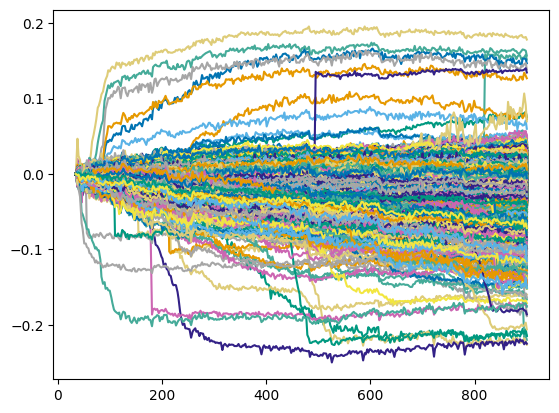

In [26]:
plt.plot(timestamps, ori_curves.T, label='Example Curve')
plt.show()

In [27]:
timestamps.shape

(334,)

In [28]:
# # ====================================================================
# # DERIVATIVE TRUNCATION CALCULATION
# # ====================================================================
# def get_derivatives(curves_batch, timestamps):
#     return Parallel(n_jobs=-1, backend="loky", batch_size='auto')(
#         delayed(sp.calculate_first_derivative)(timestamps, y) for y in curves_batch
#     )

# print("[*] Calculating derivatives for truncation...")
# ori_curve_dydx = np.array(get_derivatives(ori_curves, timestamps))
# min_indices = np.argmin(ori_curve_dydx, axis=1)

# unique_indices, counts = np.unique(min_indices, return_counts=True)
# threshold = len(ori_curve_dydx) / 3
# significant_indices = unique_indices[counts > threshold]

# max_significant_index = np.max(significant_indices) if len(significant_indices) > 0 else None

# print(f"Indices with >1/3 contribution: {significant_indices}")
# print(f"Max index with >1/3 contribution: {max_significant_index}")
# print(f"Total curves: {len(ori_curve_dydx)}, Threshold: {threshold:.0f}")

# # Truncate and Baseline Subtract
# if max_significant_index is not None:
#     truncated_curves = ori_curves[:, max_significant_index + 1:]
#     truncated_timestamps = timestamps[max_significant_index + 1:]
# else:
#     print("[-] No significant truncation point found. Using original curves.")
#     truncated_curves = ori_curves
#     truncated_timestamps = timestamps
    
# truncated_curves_bs = truncated_curves - truncated_curves[:, 0:1]

In [29]:
np.unique(vref_idx)

array([0])


=== RUNNING PIPELINE: ORIGINAL CURVES ===

--- STAGE 1: Matrix Grid (Well vs VREF) ---


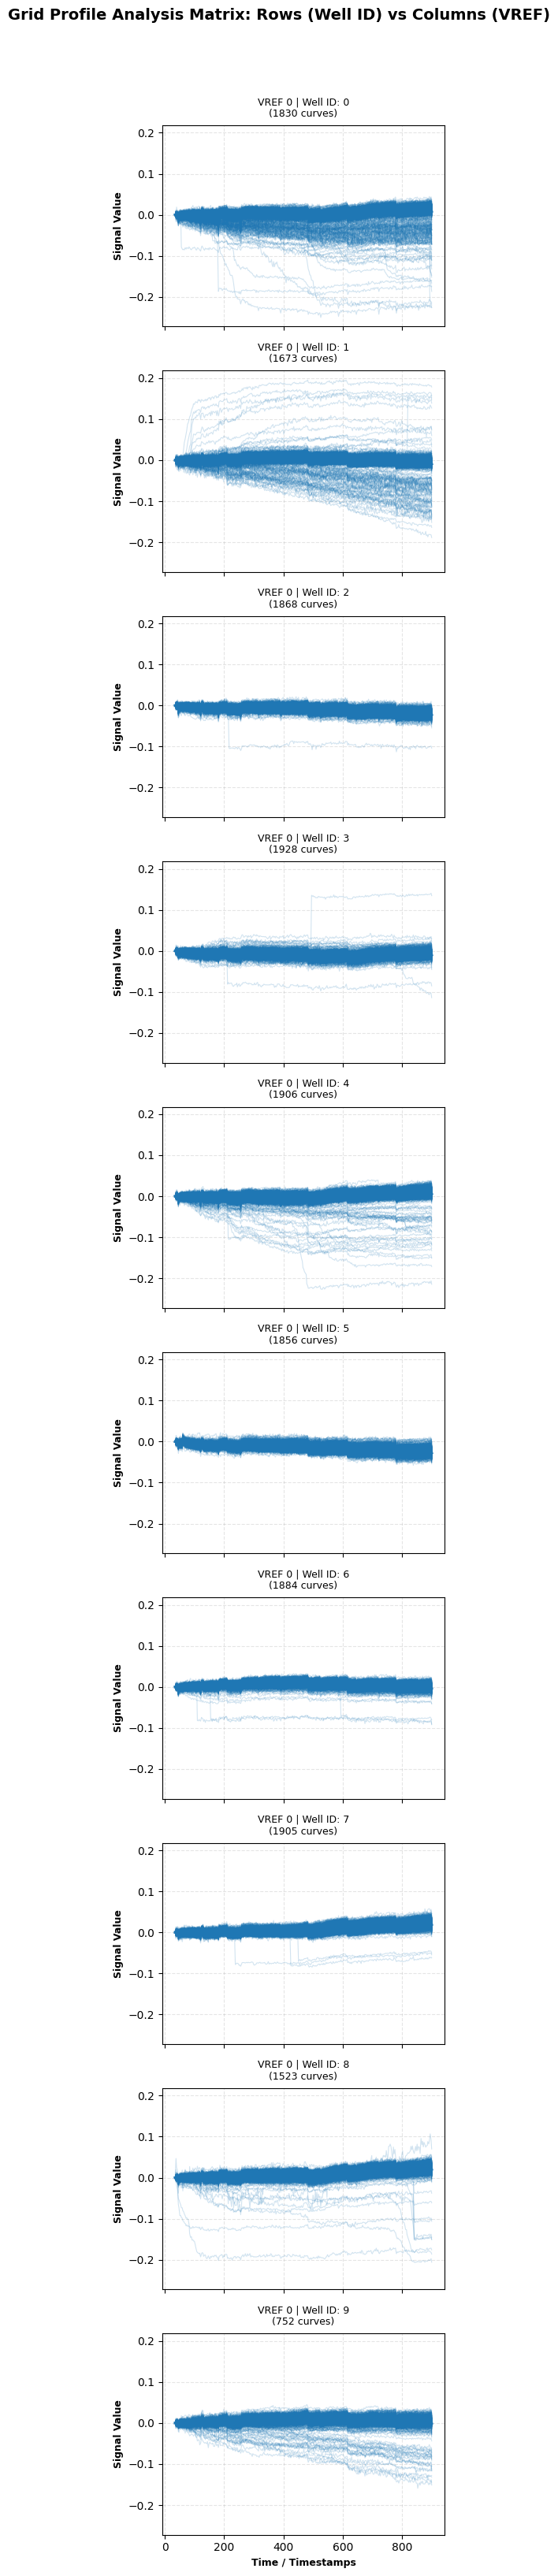


--- STAGE 2: Matrix Grid (Target Label vs VREF) ---


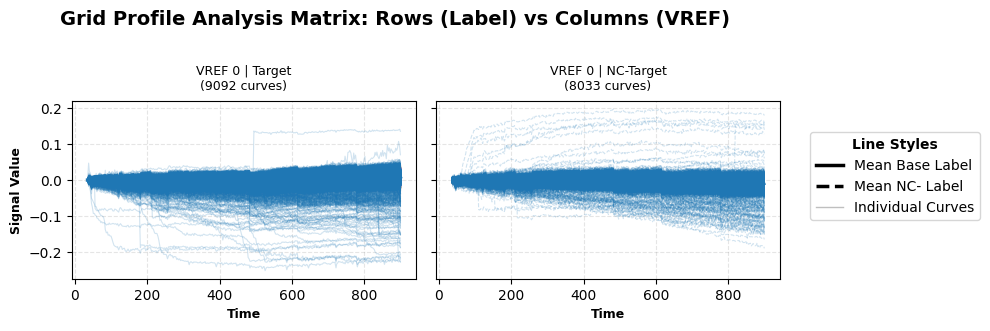


--- STAGE 3: Paired Average Analysis ---
[*] Calculating averages grouped by Label, Well ID, and VREF...


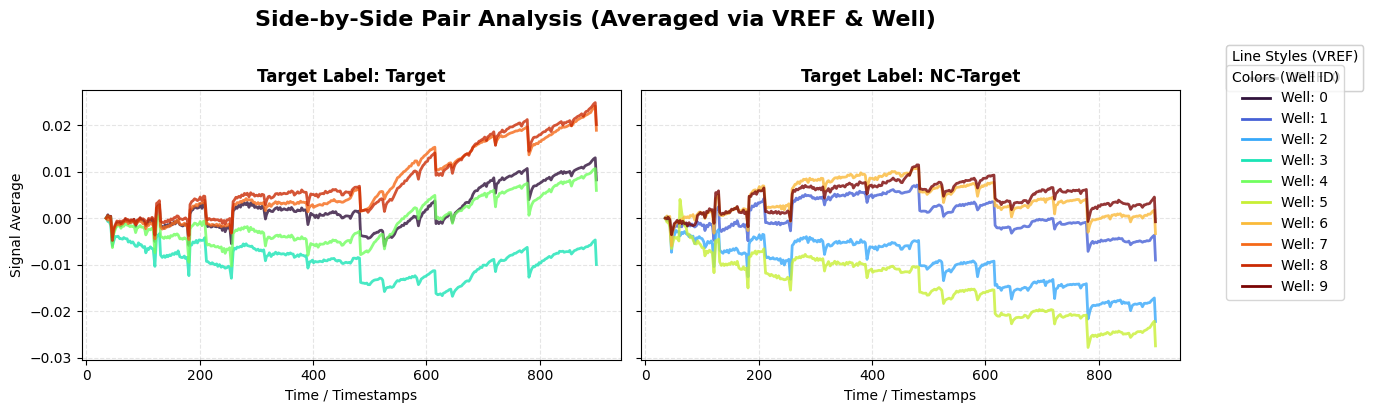


--- STAGE 4: NC Subtraction (Delta) Analysis ---
[*] Plotting paired Delta Analysis (Color=Well, Style=VREF)...


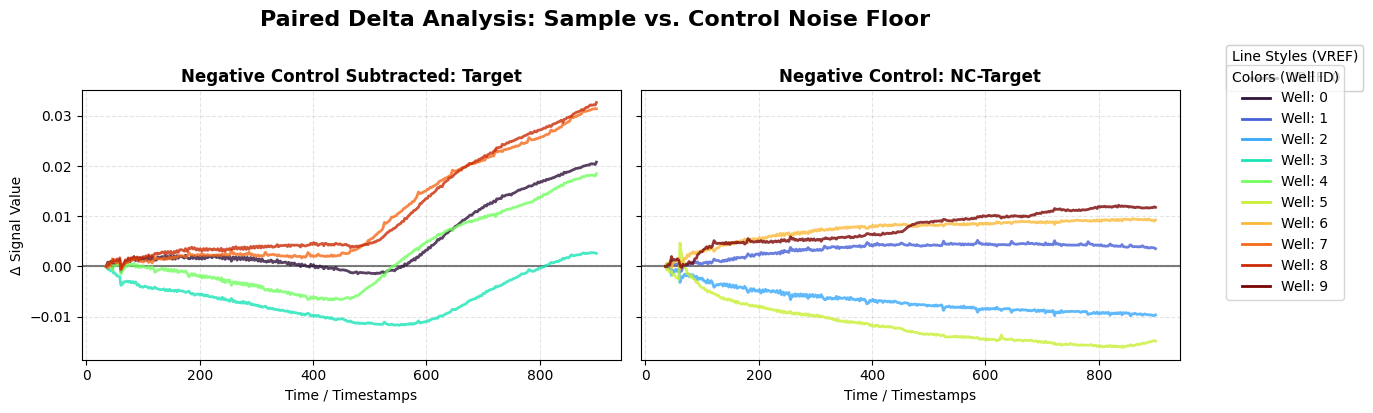


--- STAGE 5: Class Separability ---
[*] Plotting Comparative Class Separability (Time Domain Only)...


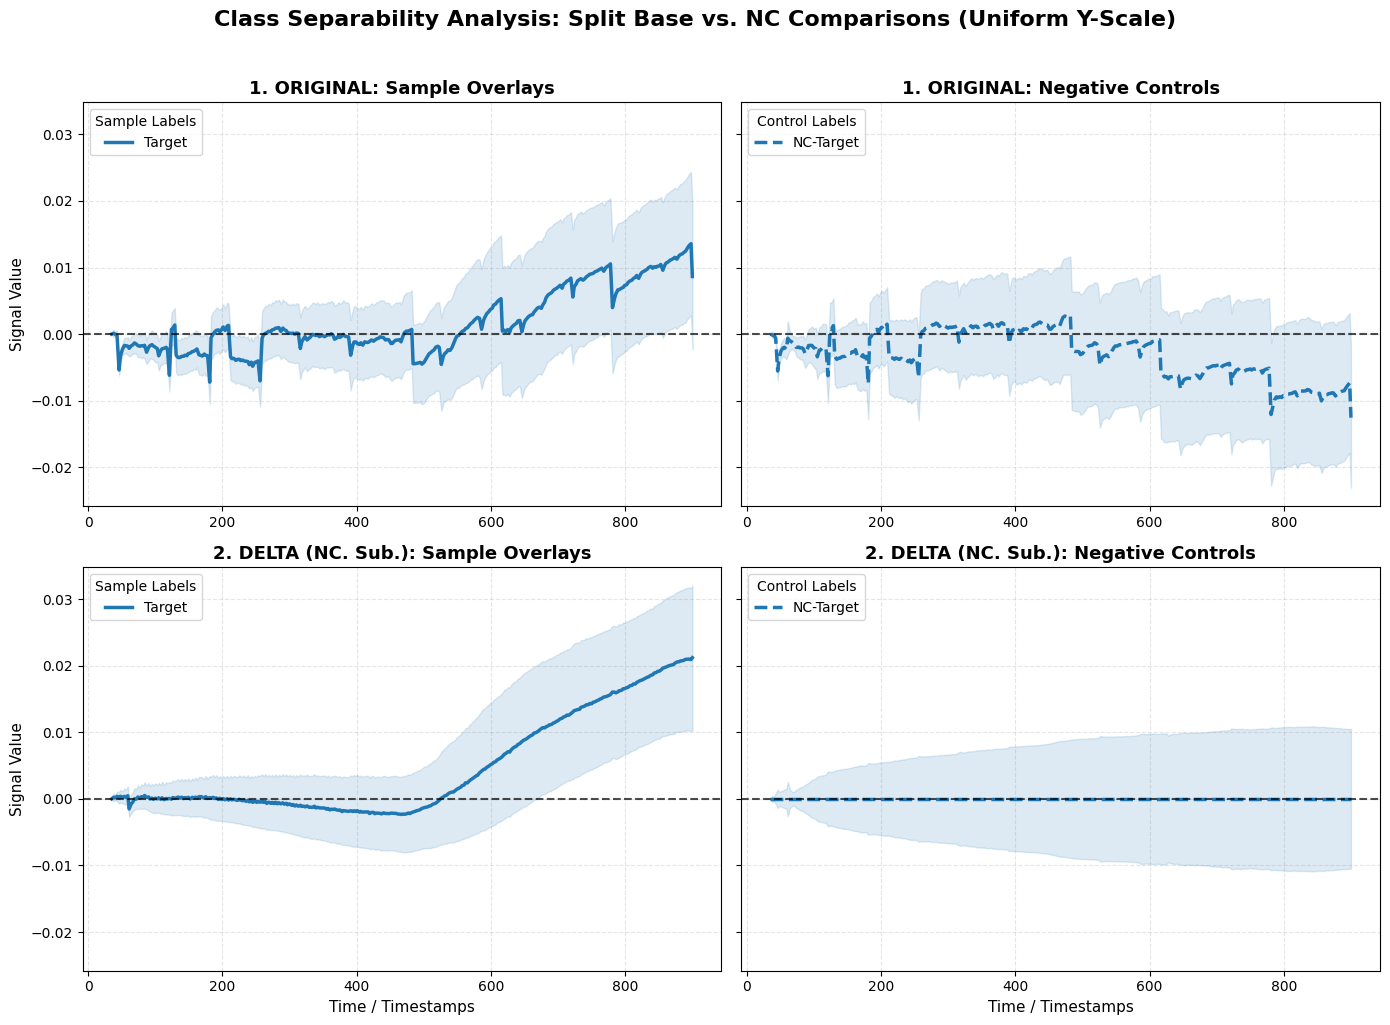

In [32]:
print("\n=== RUNNING PIPELINE: ORIGINAL CURVES ===")
plot_pipeline(
    timestamps, 
    ori_curves, 
    y_well, 
    y_label, 
    vref_idx, 
    # prefix="original_"
)